In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

In [25]:
df = pd.read_csv("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/data/master_dataset.csv")
df.head(10)

,Industry,Stage,Country,Funds_Raised,Cash_Reserves,Profit_Margin,Revenue_Growth,Laid_Off
0,Hardware,Post-IPO,United States,1200.0,9.094300e+10,0.195879,0.045113,0
1,Hardware,Post-IPO,United States,1200.0,7.682600e+10,0.258034,0.722449,0
2,Hardware,Post-IPO,United States,1200.0,6.983400e+10,0.263775,-0.196116,0
3,Hardware,Post-IPO,United States,1200.0,6.169600e+10,0.267014,-0.090976,0
4,Hardware,Post-IPO,United States,1200.0,6.263900e+10,0.246533,0.023651,0
5,Hardware,Post-IPO,United States,1200.0,6.391300e+10,0.279398,0.486864,0
6,Hardware,Post-IPO,United States,1200.0,5.151100e+10,0.257098,-0.215152,0
7,Hardware,Post-IPO,United States,1200.0,4.823100e+10,0.234357,-0.147197,0
8,Hardware,Post-IPO,United States,1200.0,4.830400e+10,0.229860,0.086633,0
9,Hardware,Post-IPO,United States,1200.0,5.135500e+10,0.256056,0.299603,0


In [26]:
# Drop columns that are not features
# - Company: just a name, not a signal
# - Date: used for alignment, not a feature
# - Date_Added: metadata
# - Source: URL, not a feature
# - List_of_Employees_Laid_Off: text, not useful here
# - Laid_Off_Count: leakage - you don't know this before a layoff
# - Laid_Off_Count_Log: same, leakage
# - Percentage: same, leakage
# - Location_HQ: too granular, Country covers this

cols_to_drop = ['Ticker','Company', 'Date', 'Laid_Off_Count', 
                'Laid_Off_Count_Log', 'Percentage']

df_model = df.drop(columns=cols_to_drop, errors='ignore')

print(df_model.shape)
print(df_model.columns.tolist())

(1301, 8)
['Industry', 'Stage', 'Country', 'Funds_Raised', 'Cash_Reserves', 'Profit_Margin', 'Revenue_Growth', 'Laid_Off']


In [27]:
df_model.isnull().sum()

Industry          0
Stage             0
Country           0
Funds_Raised      0
Cash_Reserves     0
Profit_Margin     0
Revenue_Growth    0
Laid_Off          0
dtype: int64

In [28]:
df_model["Funds_Raised"] = df_model["Funds_Raised"].fillna(0)

for col in ["Cash_Reserves", "Profit_Margin", "Revenue_Growth"]:
    median_val = df_model[col].median()

    df_model[col] = df_model[col].fillna(median_val)

df_model.isnull().sum()

Industry          0
Stage             0
Country           0
Funds_Raised      0
Cash_Reserves     0
Profit_Margin     0
Revenue_Growth    0
Laid_Off          0
dtype: int64

In [29]:
# Check unique values first
print(f"Industry unique: {df_model['Industry'].nunique()}")
print(f"Stage unique: {df_model['Stage'].nunique()}")
print(f"Country unique: {df_model['Country'].nunique()}")

Industry unique: 25
Stage unique: 2
Country unique: 1


In [30]:
X = df_model.drop(columns="Laid_Off")
y = df_model["Laid_Off"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify= y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1040, 7)
(261, 7)
(1040,)
(261,)


In [32]:
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train[["Industry", "Stage", "Country"]] = oe.fit_transform(X_train[["Industry", "Stage", "Country"]])

X_test[["Industry", "Stage", "Country"]] = oe.transform(X_test[["Industry", "Stage", "Country"]])

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

import pickle 
import json

with open("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/models/ordinal_encoder.pkl", "wb") as f:

    pickle.dump(oe,f)

X_train.head(10)

(1040, 7)
(261, 7)
(1040,)
(261,)


,Industry,Stage,Country,Funds_Raised,Cash_Reserves,Profit_Margin,Revenue_Growth
601,0.0,0.0,0.0,57.0,4.073800e+10,0.144660,0.160605
24,13.0,1.0,0.0,2.0,1.014400e+09,0.296124,0.045113
87,2.0,1.0,0.0,311.0,3.177630e+08,-0.803972,0.045113
558,23.0,1.0,0.0,4900.0,1.807048e+09,-0.380769,0.131540
845,0.0,1.0,0.0,857.0,3.132964e+09,-0.298253,-0.055620
77,21.0,1.0,0.0,35.0,1.098073e+09,0.133962,0.067405
317,0.0,1.0,0.0,719.0,2.152892e+09,-0.689372,1.224073
616,15.0,1.0,0.0,1.0,1.044270e+11,0.346198,0.002085
530,8.0,1.0,0.0,12.0,3.869600e+10,0.442053,-0.105953
1135,15.0,1.0,0.0,168.0,6.968410e+08,-0.072662,0.031889


In [33]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Industry          0
Stage             0
Country           0
Funds_Raised      0
Cash_Reserves     0
Profit_Margin     0
Revenue_Growth    0
dtype: int64
Industry          0
Stage             0
Country           0
Funds_Raised      0
Cash_Reserves     0
Profit_Margin     0
Revenue_Growth    0
dtype: int64


In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [35]:
print("\nAfter SMOTE:")
print(f"Label 0: {(y_train_balanced == 0).sum()}")
print(f"Label 1: {(y_train_balanced == 1).sum()}")
print(f"\nNew train shape: {X_train_balanced.shape}")


After SMOTE:
Label 0: 696
Label 1: 696

New train shape: (1392, 7)


classification report               precision    recall  f1-score   support

           0       0.74      0.82      0.78       175
           1       0.54      0.42      0.47        86

    accuracy                           0.69       261
   macro avg       0.64      0.62      0.63       261
weighted avg       0.67      0.69      0.68       261

ROC-AUC score  0.6207


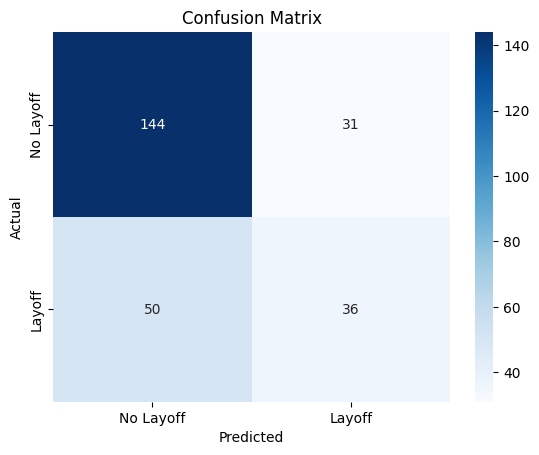

In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = XGBClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f"classification report {classification_report(y_test, y_pred)}")
print(f"ROC-AUC score {roc_auc_score(y_test, y_pred): .4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Layoff', 'Layoff'],
            yticklabels=['No Layoff', 'Layoff'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [37]:
print(X_train.columns.tolist())

['Industry', 'Stage', 'Country', 'Funds_Raised', 'Cash_Reserves', 'Profit_Margin', 'Revenue_Growth']


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model1 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)
y_prob = model1.predict_proba(X_test)[:,1]

print(f"classification report {classification_report(y_test, y_pred)}")
print(f"ROC-AUC score {roc_auc_score(y_test, y_pred): .4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Layoff', 'Layoff'],
            yticklabels=['No Layoff', 'Layoff'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()